# Special ensembles and cleaning undersamplers: full creditcard and secom

This completes the full-creditcard / out-of-sample-secom re-run (#18). Notebook 14 covered the plain undersampling story on full creditcard (baseline, class weights, RandomUnderSampler). This notebook adds the two remaining method families on the two datasets whose loaders changed:

- **special ensembles** that build resampling into the model: BalancedRandomForest, RUSBoost, EasyEnsemble;
- the **cleaning undersamplers**: TomekLinks, ENN, RENN, AllKNN, NCR, OSS, CNN, plus NearMiss;

against a Random Forest baseline and the class-weight correction. Metrics are threshold-free (ROC-AUC, average precision) with calibration (Brier, mean predicted probability) and training time, averaged over three seeds.

On creditcard (199k rows, ~30 dims) the neighbour-based cleaners degrade to brute-force k-NN and do not finish, so there we run only the row-reducers (RUS, NearMiss) and the special ensembles (which undersample internally); on secom (1096 rows) the whole cleaning suite runs. A wall-clock guard skips and logs any sampler that blows past its budget, so nothing is silently dropped.

The two datasets tell two different, complementary stories, and both land on the same conclusion.

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

res = pickle.load(open(Path('..') / 'models' / 'cleaning-special-rerun' / 'results.pkl', 'rb'))
runs = res['runs']
PRIOR = {'creditcard': 0.00173, 'secom': 0.0666}  # test-set positive rate
FAMILY_COLOR = {'reference': '#d62728', 'special_ensemble': '#1f77b4', 'undersampler': '#2ca02c'}

def frame(dataset):
    rows = [r for r in runs if r['dataset'] == dataset]
    df = pd.DataFrame([{
        'method': r['method'], 'family': r['family'],
        'ROC': r['roc_m'], 'ROC_sd': r['roc_s'],
        'AP': r['ap_m'], 'AP_sd': r['ap_s'],
        'Brier': r['brier_m'], 'mean_prob': r['mean_prob_m'], 'fit_s': r['fit_s'],
    } for r in rows])
    return df
print('methods per dataset:', {d: len(frame(d)) for d in ['creditcard', 'secom']})

methods per dataset: {'creditcard': 8, 'secom': 15}


## Creditcard (full 284k, 0.17% positive)

Watch the gap between the two columns. The special ensembles and the undersamplers reach the **highest ROC-AUC**, but the **lowest average precision** and the worst calibration (`mean_prob` far from the 0.0017 prior). class weights gives the best average precision and stays calibrated. RUSBoost collapses on average precision entirely.

In [2]:
def show(df):
    disp = df.copy()
    disp['ROC-AUC'] = disp.apply(lambda r: f"{r.ROC:.3f}±{r.ROC_sd:.3f}", axis=1)
    disp['avg precision'] = disp.apply(lambda r: f"{r.AP:.3f}±{r.AP_sd:.3f}", axis=1)
    disp['Brier'] = disp['Brier'].map(lambda v: f'{v:.1e}')
    disp['mean_prob'] = disp['mean_prob'].map(lambda v: f'{v:.3f}')
    disp['fit_s'] = disp['fit_s'].map(lambda v: f'{v:.1f}')
    return disp[['method', 'family', 'ROC-AUC', 'avg precision', 'Brier', 'mean_prob', 'fit_s']].set_index('method')

cc = frame('creditcard')
show(cc)

,family,ROC-AUC,avg precision,Brier,mean_prob,fit_s
method,,,,,,
baseline,reference,0.951±0.003,0.834±0.003,4.3e-04,0.002,142.5
class_weight,reference,0.958±0.002,0.838±0.004,4.2e-04,0.002,56.0
balanced_rf,special_ensemble,0.975±0.000,0.759±0.001,1.8e-02,0.080,1.6
rusboost,special_ensemble,0.908±0.003,0.087±0.034,2.7e-02,0.132,0.0
easyensemble,special_ensemble,0.976±0.001,0.771±0.002,1.5e-01,0.388,1.5
rus,undersampler,0.975±0.002,0.747±0.019,3.0e-02,0.111,0.2
nearmiss1,undersampler,0.889±0.001,0.558±0.051,7.3e-01,0.844,0.4
nearmiss2,undersampler,0.905±0.001,0.494±0.083,7.3e-01,0.850,2.2


### Figure 1 - the ROC / average-precision divergence on creditcard

Left: each method placed by its ROC-AUC (x) and average precision (y); marker size is the **calibration error** `|mean_prob - prior|`. The resampling methods drift to the bottom-right (high ROC, low AP, large markers = miscalibrated); the reference models sit top-left (top AP, tiny markers = calibrated). Right: mean predicted probability against the true prior (dashed) shows the same thing directly. Under a 0.17% minority, ROC-AUC is the misleading metric.

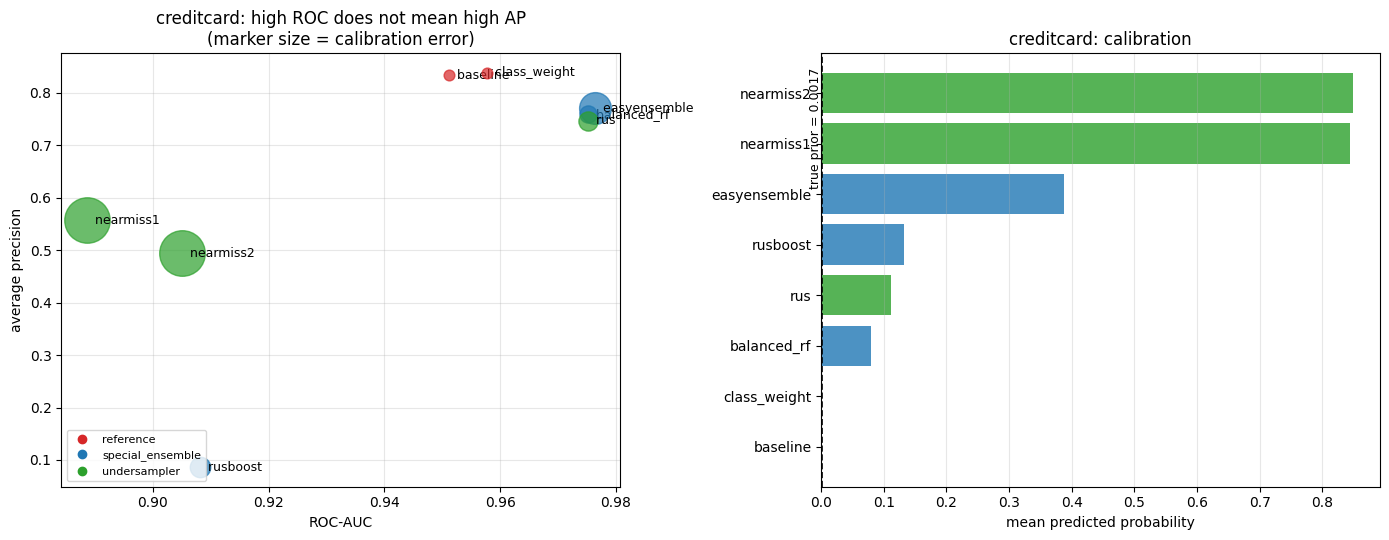

In [3]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(14, 5.5))
prior = PRIOR['creditcard']
for _, r in cc.iterrows():
    cal_err = abs(r.mean_prob - prior)
    axl.scatter(r.ROC, r.AP, s=60 + cal_err * 1200, color=FAMILY_COLOR[r.family], alpha=0.7, zorder=3)
    axl.annotate(f'  {r.method}', (r.ROC, r.AP), fontsize=9, va='center')
axl.set_xlabel('ROC-AUC'); axl.set_ylabel('average precision')
axl.set_title('creditcard: high ROC does not mean high AP\n(marker size = calibration error)')
axl.grid(alpha=0.3)
handles = [plt.Line2D([], [], marker='o', ls='', color=c, label=f) for f, c in FAMILY_COLOR.items()]
axl.legend(handles=handles, fontsize=8, loc='lower left')

order = cc.sort_values('mean_prob')
axr.barh(order['method'], order['mean_prob'], color=[FAMILY_COLOR[f] for f in order['family']], alpha=0.8)
axr.axvline(prior, color='k', ls='--', lw=1.2)
axr.annotate(f'true prior = {prior:.4f}', (prior, len(order) - 0.5), fontsize=9, rotation=90, va='top', ha='right')
axr.set_xlabel('mean predicted probability'); axr.set_title('creditcard: calibration')
axr.grid(axis='x', alpha=0.3)
fig.tight_layout(); plt.show()

## secom (out-of-sample imputation, ~6.6% positive)

A hard, high-dimensional, noisy dataset, and a different story. The **plain baseline is already the best or tied**; class weights, RUS, NearMiss and every special ensemble make it worse. Only the gentle cleaning undersamplers (ENN, RENN, AllKNN, NCR), which drop noisy majority points rather than throw most of them away, stay level with the baseline, with AllKNN nudging average precision up within the noise. NearMiss is actively destructive here, below chance ROC.

In [4]:
sec = frame('secom')
show(sec)

,family,ROC-AUC,avg precision,Brier,mean_prob,fit_s
method,,,,,,
baseline,reference,0.785±0.004,0.226±0.019,4.9e-02,0.080,1.5
class_weight,reference,0.739±0.016,0.183±0.007,5.9e-02,0.145,0.5
balanced_rf,special_ensemble,0.720±0.018,0.153±0.008,1.6e-01,0.375,0.2
rusboost,special_ensemble,0.637±0.028,0.085±0.011,1.7e-01,0.303,0.0
easyensemble,special_ensemble,0.729±0.006,0.217±0.015,2.3e-01,0.483,2.6
tomek,undersampler,0.771±0.001,0.195±0.001,5.0e-02,0.082,1.5
enn,undersampler,0.781±0.002,0.222±0.007,5.0e-02,0.098,1.1
renn,undersampler,0.757±0.002,0.237±0.008,5.4e-02,0.125,1.0
allknn,undersampler,0.787±0.008,0.253±0.025,5.0e-02,0.103,1.1


### Figure 2 - secom: baseline is already the target

ROC-AUC and average precision by method, sorted by AP, with the baseline drawn as a dashed reference. Nothing clears the baseline by more than the seed-to-seed noise; the aggressive resamplers (rus, nearmiss) and the special ensembles fall well below it.

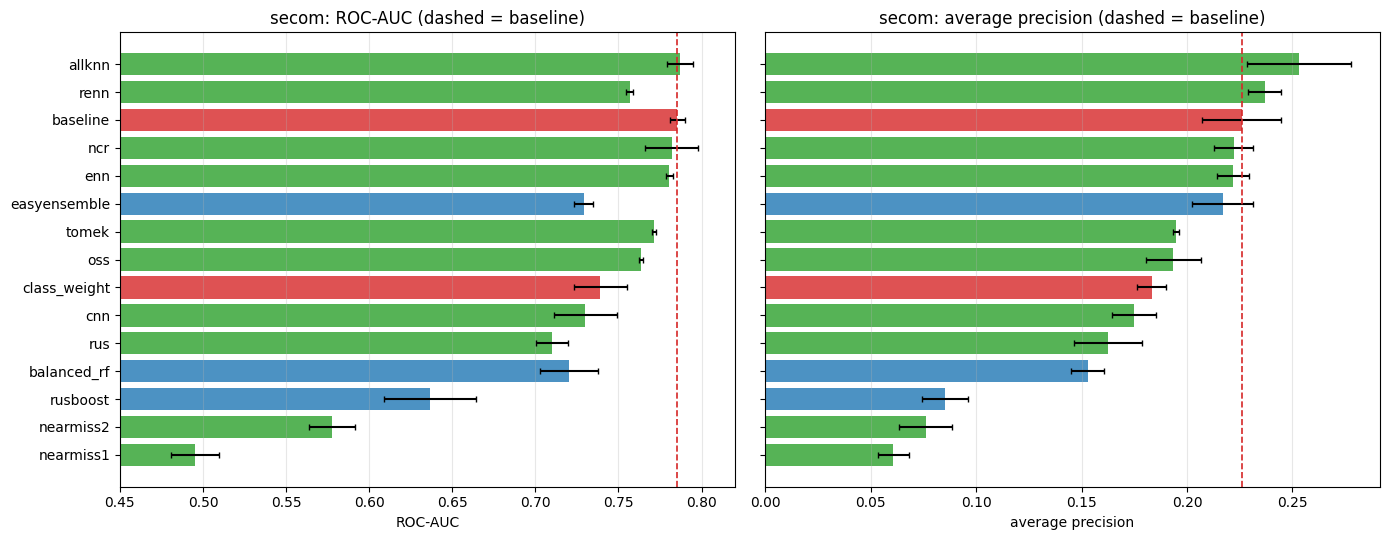

In [5]:
s = sec.sort_values('AP')
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
colors = [FAMILY_COLOR[f] for f in s['family']]
a1.barh(s['method'], s['ROC'], xerr=s['ROC_sd'], color=colors, alpha=0.8, capsize=2)
a1.axvline(sec.set_index('method').loc['baseline', 'ROC'], color='#d62728', ls='--', lw=1.2)
a1.set_xlabel('ROC-AUC'); a1.set_title('secom: ROC-AUC (dashed = baseline)'); a1.grid(axis='x', alpha=0.3)
a1.set_xlim(0.45, 0.82)
a2.barh(s['method'], s['AP'], xerr=s['AP_sd'], color=colors, alpha=0.8, capsize=2)
a2.axvline(sec.set_index('method').loc['baseline', 'AP'], color='#d62728', ls='--', lw=1.2)
a2.set_xlabel('average precision'); a2.set_title('secom: average precision (dashed = baseline)'); a2.grid(axis='x', alpha=0.3)
fig.tight_layout(); plt.show()

## Conclusion

Two datasets, two mechanisms, one conclusion.

1. **On creditcard the lesson is the metric.** The special ensembles and undersamplers post the highest ROC-AUC (0.975-0.976 vs 0.951 for the baseline), which is exactly why ROC-AUC is the wrong yardstick at 0.17% positive: on **average precision** they fall to 0.75-0.77 while class weights leads at 0.838, and they are badly miscalibrated (EasyEnsemble predicts a mean probability of 0.39 against a 0.0017 prior). RUSBoost collapses to 0.087 AP because AdaBoost's exponential loss ranks the rare positives poorly. Rank the rare positives honestly and class correction wins.

2. **On secom the lesson is that a good model needs no resampling.** The plain Random Forest is already best; class weights and aggressive undersampling both hurt, and NearMiss drops below chance. The only resampling that survives is gentle majority cleaning (ENN/AllKNN/NCR), and it only matches the baseline. So even where resampling is traditionally sold as a fix for hard imbalanced data, it ranges from neutral to harmful.

3. **Together with notebooks 14 and 15 the picture is complete.** Across plain undersampling, oversampling, special ensembles and cleaning undersamplers, and across the full-scale extreme case (creditcard) and the hard noisy case (secom), no resampling method beats a properly class-corrected, well-calibrated model on threshold-free metrics. It only ever changes the operating point, which class weights and the decision threshold control directly. That is the Elkan result, confirmed once more.

*(The one method family left un-run is the successive-halving-tuned standard ensembles on the full 199k creditcard: that search does not finish at full scale, which was the original reason for the subsample. Notebook 14 already covers full creditcard for fixed-hyperparameter Random Forest and XGBoost.)*